# Bitcoin Regime-Conditional Robustness and Temporal Stability

## Role
This notebook evaluates whether the frozen Bitcoin forecast vectors remain reliable when market conditions or evaluation periods change, rather than only looking good on aggregate (Notebook 07).

## Inputs
The authoritative frozen Bitcoin forecast matrix (`results/validated_forecasts.csv`), the canonical training target/return series, the training-defined threshold artifact (`results/bitcoin_regime_thresholds_training.csv`), the regime-conditional metrics artifact (`results/bitcoin_regime_robustness_training_defined.csv`), and the temporal-stability artifact (`results/bitcoin_temporal_stability.csv`).

## Outputs
Training-defined regime thresholds, regime sample-size evidence, regime-conditional performance, temporal-segment performance, a regime robustness ranking, and a temporal-stability ranking.

## Depends On
`07_Bitcoin_Forecast_Freeze_and_Validation.ipynb`
`08_Bitcoin_Naive_Audit.ipynb`

## Authoritative Status
`AUTHORITATIVE CONDITIONAL PERFORMANCE ANALYSIS`

## What This Notebook Does Not Do
No model training. No forecast regeneration. No uncertainty calibration. No statistical significance testing. No Trust Score synthesis. No comprehensive adversarial robustness analysis.

# 1. Objective and Research Questions

### Q1 — Regime-Conditional Robustness

> Do model errors remain controlled across different volatility and return-movement regimes defined from training data only?

### Q2 — Temporal Stability

> Does model performance remain reasonably stable across Earlier, Middle, and Later portions of the frozen test period, or is aggregate performance driven disproportionately by one temporal segment?

> All regime thresholds are estimated from training data only and are then applied unchanged to the final test period. Final-test outcomes do not determine the regime thresholds.

# 2. Setup

Standard project-root discovery. Only the frozen forecast matrix, the canonical train/test target, the training-derived threshold and derived-metric artifacts, and the repository's canonical metric helpers are loaded. No forecasting model is fit and no final forecast is recreated.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.bitcoin_pipeline import *

RUN_GENERATION = False
PROMOTE_TO_AUTHORITATIVE = False

# 3. Data and Method

## 3.1 Scope and Leakage Guardrail

> These analyses are conditional diagnostics, not comprehensive claims of robustness or universal generalisation.

This project's preferred public terminology is **Regime-Conditional Robustness** and **Temporal Stability**; "Generalisation" is avoided here except where legacy artifact column names already use it (`bitcoin_regime_robustness_training_defined.csv`'s companion artifacts use "generalisation" historically -- the underlying evidence is unchanged, only the notebook's own language is standardised).

Regime thresholds are training-defined (Section 3.2) and applied unchanged to the frozen test observations; every model is evaluated on exactly the same regime masks and the same temporal segments, so no regime or segment is tailored to any specific model.

## 3.2 Regime Definition Method

Verified directly from `src.bitcoin_pipeline.training_regime_thresholds` / `test_regime_masks`: the volatility measure is a **14-day rolling standard deviation of daily percentage returns** (`pct_change().rolling(14, min_periods=7).std()`); the movement measure is the **daily percentage return itself**. Thresholds are training-period quantiles of these two training-period series, then applied unchanged to test-period values of the same series.

In [2]:
regime_method = pd.DataFrame([
    {'Regime': 'Low Volatility', 'Training Variable': '14-day rolling std of daily % return', 'Training Rule': 'value <= training 33rd percentile', 'Interpretation': 'Calmer-than-usual short-horizon price movement'},
    {'Regime': 'High Volatility', 'Training Variable': '14-day rolling std of daily % return', 'Training Rule': 'value >= training 67th percentile', 'Interpretation': 'More turbulent-than-usual short-horizon price movement'},
    {'Regime': 'Major Upward Move', 'Training Variable': 'Daily % return', 'Training Rule': 'value >= training 80th percentile', 'Interpretation': 'Unusually large single-day price increase'},
    {'Regime': 'Major Downward Move', 'Training Variable': 'Daily % return', 'Training Rule': 'value <= training 20th percentile', 'Interpretation': 'Unusually large single-day price decrease'},
]).set_index('Regime')
regime_method

,Training Variable,Training Rule,Interpretation
Regime,,,
Low Volatility,14-day rolling std of daily % return,value <= training 33rd percentile,Calmer-than-usual short-horizon price movement
High Volatility,14-day rolling std of daily % return,value >= training 67th percentile,More turbulent-than-usual short-horizon price ...
Major Upward Move,Daily % return,value >= training 80th percentile,Unusually large single-day price increase
Major Downward Move,Daily % return,value <= training 20th percentile,Unusually large single-day price decrease


> Defining thresholds from the test set would condition the evaluation design on the outcomes being evaluated and would weaken the independence of the robustness analysis.

## 3.3 Temporal Segmentation Method

> The 1,061 final-test observations are divided chronologically into approximately equal Earlier, Middle, and Later segments, preserving order and avoiding overlap.

Verified from `src.bitcoin_pipeline.temporal_segments`: the chronological test index is split with `numpy.array_split(index, 3)`, which produces contiguous, non-overlapping, order-preserving thirds without requiring the count to divide evenly. Thirds are used because the split is simple, interpretable, model-independent, leaves enough observations per segment for a stable RMSE estimate, and is intended as a temporal-stability diagnostic rather than a formal structural-break analysis -- the three segments are not claimed to correspond to any known market regime or economic event.

# 4. Regime-Conditional Robustness Results

## 4.1 Training-Defined Thresholds

> The thresholds below are estimated once from the training period and then held fixed during final-test evaluation.

In [3]:
# Load the canonical split and the frozen forecast matrix.
_, target = load_bitcoin_target(ROOT)
train, test = canonical_split(target)
validated = load_validated_forecasts(ROOT)

thresholds = pd.read_csv(ROOT / 'results' / 'bitcoin_regime_thresholds_training.csv')
assert thresholds.Source.eq('Training data only').all()
thresholds

,Threshold,Value,Source,Training_Start,Training_End
0,volatility_low_33,0.024310,Training data only,2012-01-01 00:00:00+00:00,2023-08-11 00:00:00+00:00
1,volatility_high_67,0.037532,Training data only,2012-01-01 00:00:00+00:00,2023-08-11 00:00:00+00:00
2,return_major_up_80,0.025095,Training data only,2012-01-01 00:00:00+00:00,2023-08-11 00:00:00+00:00
3,return_major_down_20,-0.018476,Training data only,2012-01-01 00:00:00+00:00,2023-08-11 00:00:00+00:00


## 4.2 Regime Sample Sizes

> Conditional metrics are only as reliable as the number of observations supporting them. Regimes with substantially fewer test observations should be interpreted with greater uncertainty.

In [4]:
robust = pd.read_csv(ROOT / 'results' / 'bitcoin_regime_robustness_training_defined.csv')
assert robust.Model.nunique() == 10

regime_sizes = robust.groupby('Regime').N.first().to_frame('N')
regime_sizes['Share of Final Test (%)'] = 100 * regime_sizes['N'] / len(test)
regime_sizes.round(2)

,N,Share of Final Test (%)
Regime,,
High Volatility,81,7.63
Low Volatility,676,63.71
Major Downward Movement,174,16.40
Major Upward Movement,131,12.35


High Volatility is estimated from only 81 test observations (7.6% of the final test period), versus 676 for Low Volatility (63.7%) -- an 8.3x imbalance. High-volatility performance comparisons in Section 4.3-4.4 therefore carry substantially more sampling uncertainty than low-volatility comparisons, and this is not corrected for retroactively anywhere below.

## 4.3 Regime RMSE Comparison

The chart below shows RMSE for all 10 final analytical models under each of the four training-defined regimes, using identical regime masks and the identical metric for every model.

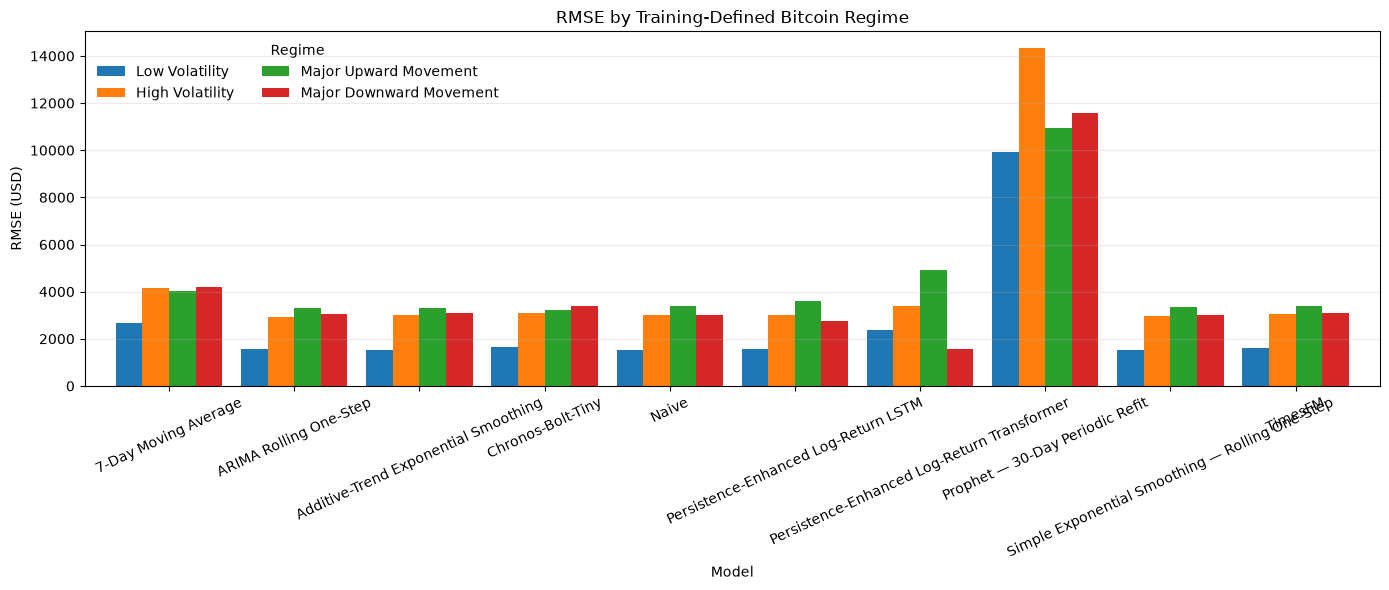

In [5]:
regime_rmse = robust.pivot(index='Model', columns='Regime', values='RMSE')
ordered_regimes = ['Low Volatility', 'High Volatility', 'Major Upward Movement', 'Major Downward Movement']
ax = regime_rmse[ordered_regimes].plot(kind='bar', figsize=(14, 6), width=0.85)
ax.set(title='RMSE by Training-Defined Bitcoin Regime', xlabel='Model', ylabel='RMSE (USD)')
ax.tick_params(axis='x', rotation=25)
ax.grid(axis='y', alpha=0.25)
ax.legend(title='Regime', frameon=False, ncol=2)
ax.figure.tight_layout()
plt.show()

Look for two things in the grouped bars: how tall the Low Volatility bar is relative to the other three for each model (a large gap indicates regime sensitivity), and whether any model's bar ordering across regimes departs from the rest -- most models track each other's regime-to-regime shape, with Prophet and the PE-Transformer visibly the tallest across every regime.

## 4.4 Regime Robustness Ranking

`RMSE Spread = max(RMSE_regime) - min(RMSE_regime)`; `Relative RMSE Spread = RMSE Spread / mean(RMSE_regime)`. Ranked by Relative RMSE Spread, lowest first: small relative spread means more stable conditional performance across regimes, large relative spread means greater regime sensitivity. This is a stability-across-regimes measure, not a universal robustness score -- a model can rank well here while still having poor absolute accuracy in every regime (see interpretation below the table).

In [6]:
regime_summary = pd.DataFrame({
    'Best Regime RMSE': regime_rmse.min(axis=1),
    'Worst Regime RMSE': regime_rmse.max(axis=1),
})
regime_summary['RMSE Spread'] = regime_summary['Worst Regime RMSE'] - regime_summary['Best Regime RMSE']
regime_summary['Relative RMSE Spread'] = regime_summary['RMSE Spread'] / regime_rmse.mean(axis=1)
regime_summary = regime_summary.sort_values('Relative RMSE Spread')
regime_summary.insert(0, 'Rank', range(1, len(regime_summary) + 1))
regime_summary.round(3)

,Rank,Best Regime RMSE,Worst Regime RMSE,RMSE Spread,Relative RMSE Spread
Model,,,,,
Prophet — 30-Day Periodic Refit,1,9909.703,14327.144,4417.440,0.378
7-Day Moving Average,2,2650.216,4183.552,1533.336,0.408
Chronos-Bolt-Tiny,3,1643.695,3376.050,1732.355,0.613
TimesFM,4,1617.794,3387.169,1769.376,0.635
ARIMA Rolling One-Step,5,1552.531,3301.094,1748.562,0.646
Additive-Trend Exponential Smoothing,6,1543.574,3313.462,1769.889,0.647
Simple Exponential Smoothing — Rolling One-Step,7,1540.742,3352.705,1811.963,0.666
Naive,8,1529.214,3370.396,1841.182,0.676
Persistence-Enhanced Log-Return LSTM,9,1553.524,3615.755,2062.231,0.755


Reading this table requires care: Prophet ranks 1st (smallest relative spread) not because it is robust, but because its RMSE is uniformly very high across every regime (its own absolute spread, ~4,417, is in fact the largest of the ten models) -- a large, consistently bad mean pulls the relative-spread ratio down. The 7-Day Moving Average shows the same pattern at rank 2. Among the models with genuinely competitive absolute accuracy, Chronos-Bolt-Tiny (rank 3) and TimesFM (rank 4) show the smallest relative regime sensitivity.

## 4.5 Bootstrap Uncertainty of Regime-Conditional RMSE

The regime RMSE values in Section 4.3/4.4 are point estimates. High Volatility in
particular is estimated from only 81 test observations (Section 4.2), so its RMSE
carries more sampling uncertainty than the bar chart alone conveys. This subsection adds
block-bootstrap confidence intervals for regime-conditional RMSE, using only the already
frozen `Actual - Forecast` error vectors for each of the ten models -- no forecast is
regenerated or altered.

**Method**: a fixed-length moving-block bootstrap (not i.i.d. resampling), because
forecast errors are time-ordered and may be serially dependent. A stationary
(geometric-block-length) bootstrap was considered but a fixed block length was chosen
instead for transparency and exact reproducibility -- the block length is stated
explicitly rather than drawn from a distribution.

**Non-contiguous regime membership**: regime dates are a scattered subset of the 1,061
test dates, not a contiguous span. Per the guardrail for this analysis, the regime's
member dates are first sorted into their original chronological order, and the moving
block bootstrap is then applied to that order-preserved subsequence (blocks are drawn
over *positions in the regime subsequence*, not over calendar days directly). This means
a "block" only approximates true calendar-adjacency to the extent that consecutive
regime-member observations are themselves temporally close -- which is checked explicitly
below before any confidence interval is reported, rather than assumed.

### Local Contiguity Diagnostic (Read Before the Bootstrap Table)

For each regime, `% Adjacent Pairs Calendar-Contiguous` is the share of consecutive pairs
in the order-preserved regime subsequence that are also exactly one calendar day apart in
the original series. A high share means the block bootstrap's implicit adjacency
assumption is close to a genuine calendar-contiguous block bootstrap; a low share means
consecutive entries in the regime subsequence are often calendar-distant, so the block
mechanism mostly concatenates near-independent points and the resulting interval should
be read as a weaker approximation.

In [7]:
def regime_contiguity_diagnostic(masks, test_index):
    rows = []
    for regime, mask in masks.items():
        idx = mask[mask.fillna(False)].index.sort_values()
        n = len(idx)
        if n < 2:
            rows.append({"Regime": regime, "N": n, "Contiguous Runs": n, "% Adjacent Pairs Calendar-Contiguous": np.nan, "Assessment": "N too small"})
            continue
        gap_days = np.diff(idx.values).astype("timedelta64[D]").astype(int)
        runs = 1 + int((gap_days > 1).sum())
        pct_adjacent = 100 * float(np.mean(gap_days == 1))
        assessment = "High (block ~ calendar-adjacent)" if pct_adjacent >= 80 else (
            "Moderate" if pct_adjacent >= 40 else "Low (block mostly bridges distant days)")
        rows.append({"Regime": regime, "N": n, "Contiguous Runs": runs,
                      "% Adjacent Pairs Calendar-Contiguous": round(pct_adjacent, 1), "Assessment": assessment})
    return pd.DataFrame(rows).set_index("Regime")

masks = test_regime_masks(target, test.index, dict(zip(thresholds.Threshold, thresholds.Value)))
contiguity = regime_contiguity_diagnostic(masks, test.index)
contiguity

,N,Contiguous Runs,% Adjacent Pairs Calendar-Contiguous,Assessment
Regime,,,,
Low Volatility,676,34,95.1,High (block ~ calendar-adjacent)
High Volatility,81,8,91.2,High (block ~ calendar-adjacent)
Major Upward Movement,131,122,6.9,Low (block mostly bridges distant days)
Major Downward Movement,174,137,21.4,Low (block mostly bridges distant days)


Low Volatility and High Volatility are highly locally contiguous (volatility clusters
into runs/episodes, a well-known stylised fact), so the order-preserving block bootstrap
for those two regimes is a reasonable approximation to a true calendar block bootstrap.
Major Upward/Downward Movement are far more scattered (large single-day moves occur
sporadically rather than in runs), so their block-bootstrap confidence intervals below
should be read as a materially weaker approximation, closer in practice to an i.i.d.
bootstrap despite the nominal block mechanism -- this is reported explicitly rather than
presented as equally rigorous evidence across all four regimes.

In [8]:
PRIMARY_BLOCK_LENGTH = 7          # documented rule: one calendar week; see markdown above
BLOCK_LENGTH_SENSITIVITY = (5, 7, 14)
N_BOOTSTRAP = 2000
BOOTSTRAP_SEED = 20240914

def moving_block_bootstrap_matrix(n, block_length, n_boot, rng):
    # (n_boot, n) matrix of resampled positional indices via a circular moving-block
    # bootstrap (wraps at the sequence end to avoid edge bias). Vectorised: no Python
    # loop over replicates.
    if n == 0:
        return np.empty((n_boot, 0), dtype=int)
    block_length = min(block_length, n)
    n_blocks = int(np.ceil(n / block_length))
    starts = rng.integers(0, n, size=(n_boot, n_blocks))
    offsets = np.arange(block_length)
    idx = (starts[:, :, None] + offsets[None, None, :]) % n
    return idx.reshape(n_boot, n_blocks * block_length)[:, :n]

def block_bootstrap_rmse(errors_ordered, block_length, n_boot, rng):
    n = len(errors_ordered)
    boot_idx = moving_block_bootstrap_matrix(n, block_length, n_boot, rng)
    boot_errors = np.asarray(errors_ordered)[boot_idx]
    return np.sqrt(np.mean(boot_errors ** 2, axis=1))

### Bootstrap Uncertainty of Regime-Conditional RMSE (Primary Block Length = 7)

In [9]:
# Not yet defined at this point in the notebook (Section 6 defines it again later, from
# the same frozen inputs) -- computed once here so Sections 4.5/4.6/5.4/7 can reuse it.
forecasts = forecast_series(validated, target)
errors = {model: (validated.Actual - forecast) for model, forecast in forecasts.items()}

regime_bootstrap_rows = []
rng = np.random.default_rng(BOOTSTRAP_SEED)
for regime, mask in masks.items():
    regime_index = mask[mask.fillna(False)].index.sort_values()
    n = len(regime_index)
    for model in FINAL_MODEL_ORDER:
        err = errors[model].loc[regime_index].to_numpy(float)
        observed_rmse = float(np.sqrt(np.mean(err ** 2)))
        boot_rmse = block_bootstrap_rmse(err, PRIMARY_BLOCK_LENGTH, N_BOOTSTRAP, rng)
        lower, upper = np.percentile(boot_rmse, [2.5, 97.5])
        regime_bootstrap_rows.append({
            "Model": model, "Regime": regime, "N": n, "RMSE": observed_rmse,
            "Bootstrap Mean RMSE": float(boot_rmse.mean()),
            "Bootstrap Lower 95%": float(lower), "Bootstrap Upper 95%": float(upper),
            "CI Width": float(upper - lower),
        })
regime_bootstrap = pd.DataFrame(regime_bootstrap_rows)
regime_bootstrap.round(2)

,Model,Regime,N,RMSE,Bootstrap Mean RMSE,Bootstrap Lower 95%,Bootstrap Upper 95%,CI Width
0,Naive,Low Volatility,676,1529.21,1529.92,1405.73,1656.78,251.06
1,Simple Exponential Smoothing — Rolling One-Step,Low Volatility,676,1540.74,1541.43,1409.00,1673.39,264.39
2,Additive-Trend Exponential Smoothing,Low Volatility,676,1543.57,1543.53,1413.35,1674.71,261.36
3,ARIMA Rolling One-Step,Low Volatility,676,1552.53,1551.87,1417.56,1682.98,265.42
4,7-Day Moving Average,Low Volatility,676,2650.22,2641.83,2349.28,2938.91,589.63
5,Prophet — 30-Day Periodic Refit,Low Volatility,676,9909.70,9850.17,8511.74,11103.43,2591.70
6,Persistence-Enhanced Log-Return LSTM,Low Volatility,676,1553.52,1553.46,1423.10,1681.73,258.63
7,Persistence-Enhanced Log-Return Transformer,Low Volatility,676,2384.56,2382.44,2205.54,2560.16,354.62
8,Chronos-Bolt-Tiny,Low Volatility,676,1643.70,1643.93,1505.83,1776.18,270.36
9,TimesFM,Low Volatility,676,1617.79,1616.01,1481.59,1745.08,263.49


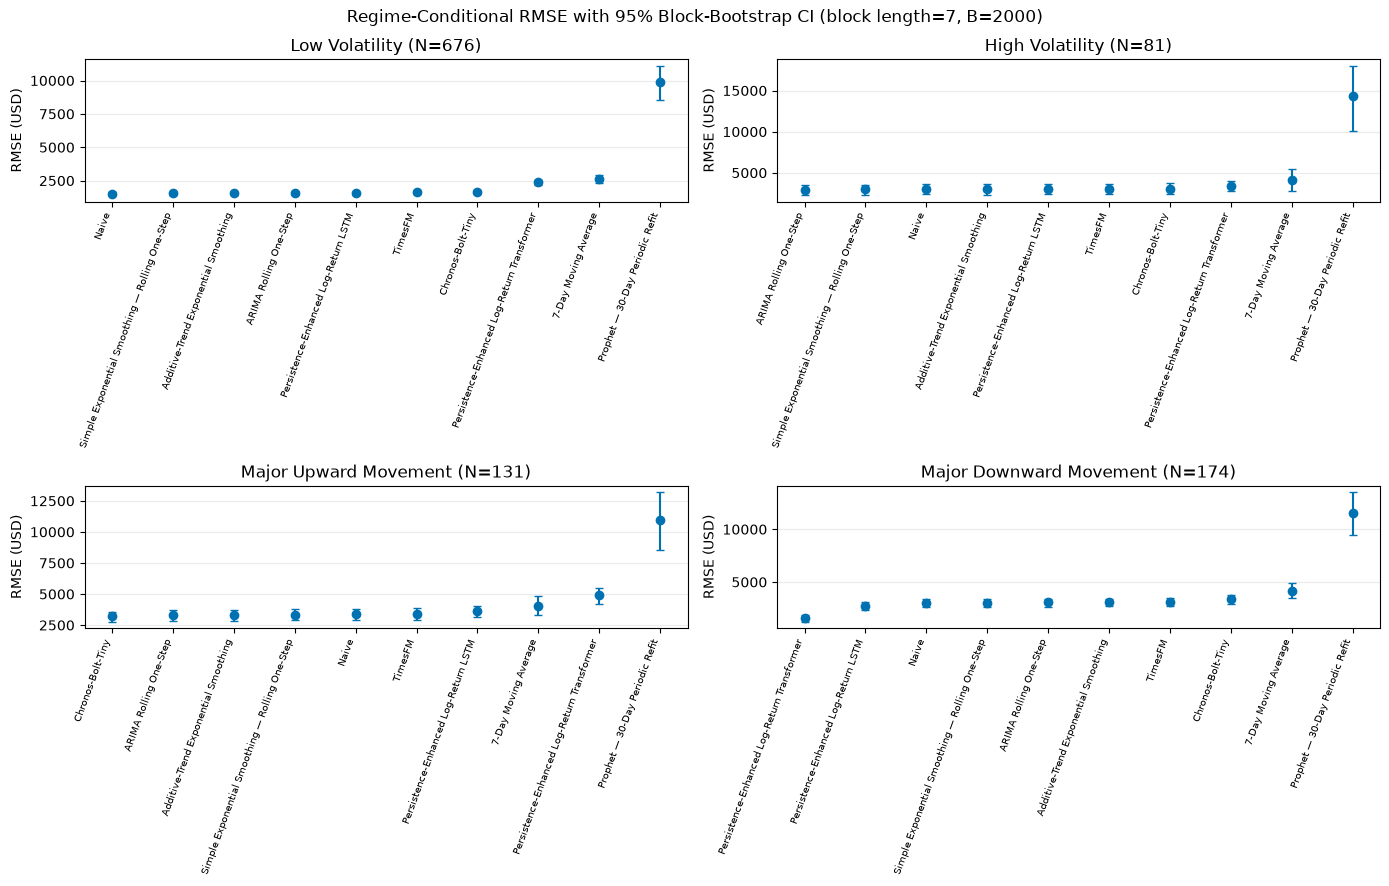

In [10]:
fig, axs = plt.subplots(2, 2, figsize=(14, 9), sharex=False)
for ax, regime in zip(axs.ravel(), masks.keys()):
    sub = regime_bootstrap[regime_bootstrap.Regime == regime].sort_values("RMSE")
    x = np.arange(len(sub))
    lower_err = sub["RMSE"] - sub["Bootstrap Lower 95%"]
    upper_err = sub["Bootstrap Upper 95%"] - sub["RMSE"]
    ax.errorbar(x, sub["RMSE"], yerr=[lower_err.clip(lower=0), upper_err.clip(lower=0)], fmt="o", capsize=3, color="#0072B2")
    ax.set_xticks(x, sub["Model"], rotation=70, ha="right", fontsize=7)
    ax.set(title=f"{regime} (N={int(sub.N.iloc[0])})", ylabel="RMSE (USD)")
    ax.grid(axis="y", alpha=0.25)
fig.suptitle(f"Regime-Conditional RMSE with {int(100*.95)}% Block-Bootstrap CI (block length={PRIMARY_BLOCK_LENGTH}, B={N_BOOTSTRAP})")
fig.tight_layout()
plt.show()

### Block-Length Sensitivity

CI width is reported for block lengths 5, 7, and 14; 7 remains the predefined primary
value used everywhere else in this notebook and in downstream sections.

In [11]:
sensitivity_rows = []
rng = np.random.default_rng(BOOTSTRAP_SEED)  # re-seeded identically per block length for comparability
for block_length in BLOCK_LENGTH_SENSITIVITY:
    for regime, mask in masks.items():
        regime_index = mask[mask.fillna(False)].index.sort_values()
        for model in FINAL_MODEL_ORDER:
            err = errors[model].loc[regime_index].to_numpy(float)
            boot_rmse = block_bootstrap_rmse(err, block_length, N_BOOTSTRAP, rng)
            lower, upper = np.percentile(boot_rmse, [2.5, 97.5])
            sensitivity_rows.append({"Block Length": block_length, "Regime": regime, "Model": model, "CI Width": float(upper - lower)})
block_sensitivity = pd.DataFrame(sensitivity_rows)
block_sensitivity.groupby(["Regime", "Block Length"])["CI Width"].mean().unstack("Block Length").round(1)

Block Length,5,7,14
Regime,,,
High Volatility,2019.9,2067.6,1988.1
Low Volatility,501.3,532.1,619.7
Major Downward Movement,1097.8,1146.2,1215.8
Major Upward Movement,1256.2,1346.2,1549.5


CI width does not scale cleanly with block length for the two smaller regimes (High Volatility, N=81, is essentially flat/non-monotonic across 5/7/14; the two larger regimes show a clearer increase, as expected -- longer blocks transmit more within-block correlation into the resampled statistic's variance). More importantly, the *ordering* of models by CI width within each regime is largely preserved across block lengths (Spearman rank correlation of CI width between block length 5 and 14 is 0.82-0.93 across the four regimes; between 7 and 14 it is 0.83-0.95), so the choice of primary block length (7) is not materially driving which models look more or less uncertain relative to each other, even where the absolute CI width itself is noisy.

## 4.6 Regime Definition Sensitivity

The primary training-defined thresholds (33rd/67th percentile volatility; 80th/20th
percentile movement, Section 4.1) remain authoritative and are **not** replaced here.
This subsection asks a narrower question: are the regime-conditional *rankings* of models
sensitive to reasonable alternative percentile cut-offs, when those alternatives are
derived from training data only and applied unchanged to the same frozen test
observations? Two single-dimension sensitivity specifications are used, each changing
only one regime family so the comparison isolates one design choice at a time:

- **Volatility Sensitivity (25th/75th percentile)** -- stricter than the primary 33rd/67th
  split, in the same direction (rarer, more extreme regime membership). Affects Low/High
  Volatility only.
- **Movement Sensitivity (10th/90th percentile)** -- stricter than the primary 80th/20th
  split, in the same direction. Affects Major Upward/Downward Movement only.

Both alternatives move in the *same* direction as the primary definition (stricter,
smaller regimes) rather than an arbitrary mix, so the two threshold families remain
consistent with each other.

In [12]:
def sensitivity_thresholds(train, vol_low_q, vol_high_q, move_up_q, move_down_q):
    returns = train.pct_change()
    volatility = returns.rolling(14, min_periods=7).std()
    return {
        "volatility_low_33": float(volatility.quantile(vol_low_q)),
        "volatility_high_67": float(volatility.quantile(vol_high_q)),
        "return_major_up_80": float(returns.quantile(move_up_q)),
        "return_major_down_20": float(returns.quantile(move_down_q)),
    }

primary_thresholds = dict(zip(thresholds.Threshold, thresholds.Value))
volatility_sensitivity_thresholds = sensitivity_thresholds(train, 0.25, 0.75, 0.80, 0.20)
movement_sensitivity_thresholds = sensitivity_thresholds(train, 0.33, 0.67, 0.90, 0.10)

primary_masks = test_regime_masks(target, test.index, primary_thresholds)
volatility_sensitivity_masks = test_regime_masks(target, test.index, volatility_sensitivity_thresholds)
movement_sensitivity_masks = test_regime_masks(target, test.index, movement_sensitivity_thresholds)

def regime_rmse_ranking(mask, regime_name, actual, forecasts):
    index = mask[mask.fillna(False)].index
    ranked = pd.Series({model: rmse(actual.loc[index], forecasts[model].loc[index]) for model in FINAL_MODEL_ORDER}, name="RMSE")
    return ranked.sort_values()

threshold_sensitivity_rows = []
spec_regimes = [
    ("Volatility Sensitivity (25th/75th)", "Low Volatility", volatility_sensitivity_masks),
    ("Volatility Sensitivity (25th/75th)", "High Volatility", volatility_sensitivity_masks),
    ("Movement Sensitivity (10th/90th)", "Major Upward Movement", movement_sensitivity_masks),
    ("Movement Sensitivity (10th/90th)", "Major Downward Movement", movement_sensitivity_masks),
]
for spec_name, regime_name, spec_masks in spec_regimes:
    primary_rank = regime_rmse_ranking(primary_masks[regime_name], regime_name, validated.Actual, forecasts)
    sensitivity_rank = regime_rmse_ranking(spec_masks[regime_name], regime_name, validated.Actual, forecasts)
    common_models = primary_rank.index
    rho, _ = stats.spearmanr(primary_rank.rank()[common_models], sensitivity_rank.rank()[common_models])
    threshold_sensitivity_rows.append({
        "Threshold Specification": spec_name, "Regime": regime_name,
        "Rank 1": sensitivity_rank.index[0], "Rank 2": sensitivity_rank.index[1], "Rank 3": sensitivity_rank.index[2],
        "Spearman Rank Correlation vs Primary": rho,
        "N (sensitivity)": int((spec_masks[regime_name].fillna(False)).sum()),
        "N (primary)": int((primary_masks[regime_name].fillna(False)).sum()),
    })
threshold_sensitivity = pd.DataFrame(threshold_sensitivity_rows)
threshold_sensitivity.round(3)

,Threshold Specification,Regime,Rank 1,Rank 2,Rank 3,Spearman Rank Correlation vs Primary,N (sensitivity),N (primary)
0,Volatility Sensitivity (25th/75th),Low Volatility,Naive,Simple Exponential Smoothing — Rolling One-Step,Additive-Trend Exponential Smoothing,1.000,486,676
1,Volatility Sensitivity (25th/75th),High Volatility,ARIMA Rolling One-Step,Simple Exponential Smoothing — Rolling One-Step,Chronos-Bolt-Tiny,0.782,46,81
2,Movement Sensitivity (10th/90th),Major Upward Movement,Chronos-Bolt-Tiny,ARIMA Rolling One-Step,TimesFM,0.927,42,131
3,Movement Sensitivity (10th/90th),Major Downward Movement,Persistence-Enhanced Log-Return Transformer,Persistence-Enhanced Log-Return LSTM,Naive,1.000,55,174


Interpretation guide (not a fixed statistical threshold, a descriptive convention used
only in this subsection): Spearman correlation `>= 0.8` is read as **stable ranking**,
`0.5-0.8` as **moderate ranking sensitivity**, and `< 0.5` as **substantial sensitivity**.
Robustness to threshold design is only claimed for regimes where the correlation above
actually falls in the stable range -- it is not assumed for all four.

# 5. Temporal Stability Results

## 5.1 Balanced Segment Definition

Temporal stability is assessed by evaluating the same frozen forecast vectors separately over three chronological portions of the final test period.

In [13]:
stability = pd.read_csv(ROOT / 'results' / 'bitcoin_temporal_stability.csv')
assert stability.Model.nunique() == 10

segment_definition = stability.groupby('Segment').agg(Start=('Start', 'first'), End=('End', 'first'), N=('N', 'first')).loc[['Earlier', 'Middle', 'Later']]
segment_definition['Share (%)'] = 100 * segment_definition['N'] / len(test)
segment_definition.round(2)

,Start,End,N,Share (%)
Segment,,,,
Earlier,2023-08-12 00:00:00+00:00,2024-07-30 00:00:00+00:00,354,33.36
Middle,2024-07-31 00:00:00+00:00,2025-07-19 00:00:00+00:00,354,33.36
Later,2025-07-20 00:00:00+00:00,2026-07-07 00:00:00+00:00,353,33.27


354 + 354 + 353 = 1,061, confirming the three segments are approximately balanced (within one observation of an exact third) and sum to the full final test period with no overlap.

## 5.2 Segment RMSE Comparison

RMSE for all 10 models across the Earlier, Middle, and Later segments, using identical segment boundaries for every model.

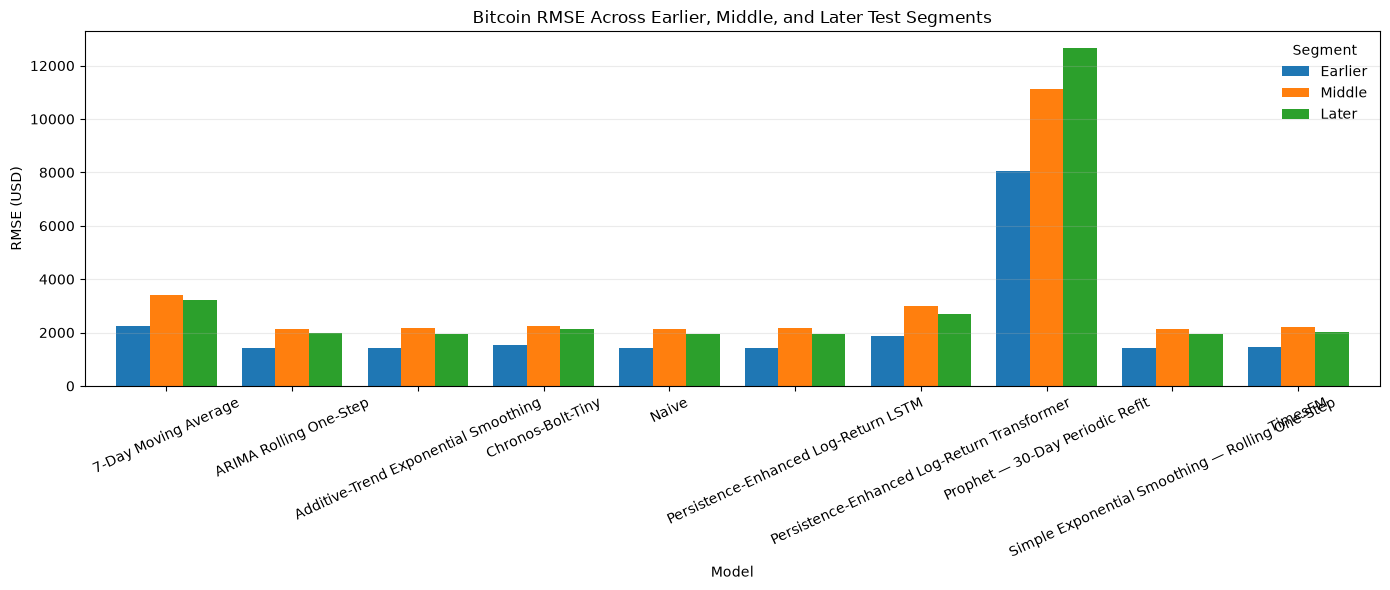

In [14]:
segment_rmse = stability.pivot(index='Model', columns='Segment', values='RMSE')
ax = segment_rmse[['Earlier', 'Middle', 'Later']].plot(kind='bar', figsize=(14, 6), width=0.8)
ax.set(title='Bitcoin RMSE Across Earlier, Middle, and Later Test Segments', xlabel='Model', ylabel='RMSE (USD)')
ax.tick_params(axis='x', rotation=25)
ax.grid(axis='y', alpha=0.25)
ax.legend(title='Segment', frameon=False)
ax.figure.tight_layout()
plt.show()

Every model's Earlier bar is visibly the shortest of its three, and Middle and Later are broadly comparable to each other for most models -- consistent with the Section 5.3 finding that the Earlier segment is the easiest across the board, not with any single model behaving unusually in one segment.

## 5.3 Temporal Stability Ranking

Same formulas as Section 4.4, applied across the three temporal segments: `RMSE Spread = max(RMSE_segment) - min(RMSE_segment)`; `Relative Spread = RMSE Spread / mean(RMSE_segment)`. Ranked by Relative Spread, lowest (most temporally stable) first.

In [15]:
segment_summary = segment_rmse[['Earlier', 'Middle', 'Later']].copy()
segment_summary['RMSE Spread'] = segment_rmse[['Earlier', 'Middle', 'Later']].max(axis=1) - segment_rmse[['Earlier', 'Middle', 'Later']].min(axis=1)
segment_summary['Relative Spread'] = segment_summary['RMSE Spread'] / segment_rmse[['Earlier', 'Middle', 'Later']].mean(axis=1)
segment_summary = segment_summary.sort_values('Relative Spread')
segment_summary.insert(0, 'Rank', range(1, len(segment_summary) + 1))
segment_summary.round(3)

Segment,Rank,Earlier,Middle,Later,RMSE Spread,Relative Spread
Model,,,,,,
Chronos-Bolt-Tiny,1,1531.947,2247.404,2128.870,715.457,0.363
7-Day Moving Average,2,2246.463,3394.693,3228.992,1148.231,0.388
Additive-Trend Exponential Smoothing,3,1428.903,2164.031,1945.716,735.129,0.398
Simple Exponential Smoothing — Rolling One-Step,4,1410.172,2142.310,1937.529,732.138,0.400
Naive,5,1408.715,2142.907,1931.860,734.191,0.402
ARIMA Rolling One-Step,6,1402.662,2150.117,1964.653,747.455,0.406
Persistence-Enhanced Log-Return LSTM,7,1429.052,2186.023,1948.165,756.971,0.408
TimesFM,8,1447.154,2221.896,2019.310,774.742,0.409
Prophet — 30-Day Periodic Refit,9,8067.195,11119.227,12653.359,4586.165,0.432


## 5.4 Distributional Stability Across Test Segments

Section 5.2/5.3 compare Earlier/Middle/Later segments using summary RMSE. This
subsection adds a formal pairwise distributional comparison: a two-sample
Kolmogorov-Smirnov test on each model's per-observation error distribution between
segments.

**Residual definition**: this subsection asks whether a model's *predictive-loss*
distribution (the magnitude of error) shifts across segments -- the same magnitude-based
framing already used for RMSE throughout Section 5 -- so **absolute error**
(`|Actual - Forecast|`) is used, not signed residual. Signed residual would instead test
for a shift in directional bias, a different question not otherwise explored in this
notebook, and the two are not mixed.

**Statistical setup**: for each of the 10 models, three pairwise KS tests (Earlier vs
Middle, Earlier vs Later, Middle vs Later) are run, giving 30 tests in total.
`H0`: the two segments' absolute-error distributions are identical. `H1`: they differ.
Sample unit: one test-date's absolute error. Segment membership is fixed (Section 5.1);
no dependence-robust correction is applied to the KS statistic itself (KS assumes i.i.d.
draws within each sample; see Limitations), but the **family-wise** multiple-testing
problem across the 30 tests is corrected with Holm's step-down procedure at
`alpha = 0.05`, for consistency with this project's Bitcoin inferential convention
(Notebook 11). This is exploratory diagnostic evidence, not a pre-registered confirmatory
test.

In [16]:
from scipy.stats import ks_2samp

segments = temporal_segments(test.index)
abs_errors = {model: (validated.Actual - forecast).abs() for model, forecast in forecasts.items()}

segment_pairs = [("Earlier", "Middle"), ("Earlier", "Later"), ("Middle", "Later")]
ks_rows = []
for model in FINAL_MODEL_ORDER:
    for seg_a, seg_b in segment_pairs:
        sample_a = abs_errors[model].loc[segments[seg_a]].to_numpy(float)
        sample_b = abs_errors[model].loc[segments[seg_b]].to_numpy(float)
        result = ks_2samp(sample_a, sample_b)
        ks_rows.append({"Model": model, "Segment A": seg_a, "Segment B": seg_b,
                         "KS Statistic": result.statistic, "Raw p": result.pvalue})
ks_table = pd.DataFrame(ks_rows)
ks_table["Holm p"] = holm_adjust(ks_table["Raw p"])
ks_table["Significant?"] = ks_table["Holm p"] < 0.05
ks_table.round(4)

,Model,Segment A,Segment B,KS Statistic,Raw p,Holm p,Significant?
0,Naive,Earlier,Middle,0.2232,0.0000,0.0000,True
1,Naive,Earlier,Later,0.2304,0.0000,0.0000,True
2,Naive,Middle,Later,0.0675,0.3659,1.0000,False
3,Simple Exponential Smoothing — Rolling One-Step,Earlier,Middle,0.2345,0.0000,0.0000,True
4,Simple Exponential Smoothing — Rolling One-Step,Earlier,Later,0.2421,0.0000,0.0000,True
5,Simple Exponential Smoothing — Rolling One-Step,Middle,Later,0.0591,0.5324,1.0000,False
6,Additive-Trend Exponential Smoothing,Earlier,Middle,0.2260,0.0000,0.0000,True
7,Additive-Trend Exponential Smoothing,Earlier,Later,0.2307,0.0000,0.0000,True
8,Additive-Trend Exponential Smoothing,Middle,Later,0.0669,0.3805,1.0000,False
9,ARIMA Rolling One-Step,Earlier,Middle,0.2514,0.0000,0.0000,True


### Per-Model Summary

In [17]:
ks_summary = ks_table.groupby("Model").agg(
    **{"Significant Segment-Pair Shifts": ("Significant?", "sum"), "Max KS Statistic": ("KS Statistic", "max")}
).sort_values("Significant Segment-Pair Shifts", ascending=False)
ks_summary

,Significant Segment-Pair Shifts,Max KS Statistic
Model,,
Prophet — 30-Day Periodic Refit,3,0.249780
7-Day Moving Average,2,0.234463
ARIMA Rolling One-Step,2,0.251412
Additive-Trend Exponential Smoothing,2,0.230726
Naive,2,0.230438
Chronos-Bolt-Tiny,2,0.259887
Persistence-Enhanced Log-Return LSTM,2,0.242938
Persistence-Enhanced Log-Return Transformer,2,0.327684
Simple Exponential Smoothing — Rolling One-Step,2,0.242058


A significant Holm-adjusted KS result is evidence of **distributional instability** in a
model's absolute-error distribution between the two segments compared -- it is not
interpreted as proof of causal concept drift, a change in the underlying data-generating
process, or a statement about *why* the distribution shifted; it only says the two
empirical distributions are statistically distinguishable under this test.

# 6. Aggregate Accuracy vs Conditional Behaviour

The canonical full 10-model ranking is recomputed here from the same frozen matrix and the same `metric_table` function Notebook 07 uses -- not re-typed from memory -- so the comparison below is against a live, verifiable source.

In [18]:
forecasts = forecast_series(validated, target)
aggregate_ranking = metric_table(validated.Actual, forecasts, train).sort_values('RMSE')
aggregate_rank = pd.Series(range(1, len(aggregate_ranking) + 1), index=aggregate_ranking.index, name='Aggregate RMSE Rank')

comparison = pd.DataFrame({
    'Aggregate RMSE Rank': aggregate_rank,
    'Regime Robustness Rank': regime_summary['Rank'],
    'Temporal Stability Rank': segment_summary['Rank'],
}).sort_values('Aggregate RMSE Rank')
comparison

,Aggregate RMSE Rank,Regime Robustness Rank,Temporal Stability Rank
Model,,,
Naive,1,8,5
Simple Exponential Smoothing — Rolling One-Step,2,7,4
ARIMA Rolling One-Step,3,5,6
Additive-Trend Exponential Smoothing,4,6,3
Persistence-Enhanced Log-Return LSTM,5,9,7
TimesFM,6,4,8
Chronos-Bolt-Tiny,7,3,1
Persistence-Enhanced Log-Return Transformer,8,10,10
7-Day Moving Average,9,2,2


The rankings diverge materially rather than matching. Naive leads aggregate accuracy (rank 1) but falls to rank 8 on regime robustness and rank 5 on temporal stability. Chronos-Bolt-Tiny is mediocre in aggregate (rank 7) but is the single most temporally stable model (rank 1) and the third-most regime-robust. TimesFM (aggregate rank 6) is reasonably regime-robust (rank 4) but among the least temporally stable (rank 8). The Persistence-Enhanced Log-Return Transformer is consistently weak across all three dimensions (ranks 8, 10, 10). Prophet and the 7-Day Moving Average rank well on both conditional-spread measures only because their errors are uniformly large rather than genuinely stable in an absolute sense (Section 4.4).

> Aggregate point accuracy and conditional reliability are not interchangeable dimensions.

No Trust Score or composite synthesis is calculated here -- that belongs to `12_Bitcoin_Trustworthiness_Synthesis.ipynb`.

# 7. Targeted Conditional Inference

This is a **targeted** inferential check on a small, pre-specified set of model pairs --
not a comprehensive 45-pair x 4-regime significance grid (which would be 180 tests and is
explicitly out of scope for this addition). The comparison set below is fixed *before*
any test statistic in this section is computed.

### Pre-Specified Comparison Set

Chosen because each pair operationalises a claim this notebook (or Notebook 11) already
makes in Key Findings, not because it was convenient or maximally significant:

1. **TimesFM vs Chronos-Bolt-Tiny** -- Section 4.4 identifies both as the most
   regime-robust models with competitive aggregate accuracy; Notebook 11 already finds
   their *aggregate* RMSE difference is not Holm-significant. This asks whether that
   near-tie also holds specifically in the regime where robustness matters most.
2. **Naive vs Chronos-Bolt-Tiny** -- operationalises this notebook's central Section 6
   finding ("Naive leads aggregate accuracy but falls to rank 8 on regime robustness")
   directly, in the regime driving that robustness ranking.
3. **Persistence-Enhanced Log-Return Transformer vs Chronos-Bolt-Tiny** -- Section 7 (Key
   Findings) singles out the PE-Transformer as "the most regime-sensitive model with
   genuinely competitive aggregate accuracy"; this tests that claim against the most
   regime-robust competitive model.
4. **TimesFM vs Naive** -- mirrors comparison 2 for the other regime-robust,
   not-top-aggregate model, completing the aggregate-vs-robustness narrative from
   Section 6.

**Regime scope**: High Volatility only. The task is deliberately narrow (Section 4.2:
High Volatility carries the most sampling uncertainty and is where the
aggregate-accuracy-vs-regime-robustness divergence is most consequential); a second
regime was considered and not added because no comparably strong, already-stated project
claim singles one out.

### Method: Why Not HAC-DM Here

`hac_dm` (Notebook 11) assumes a regularly time-ordered daily series; its Newey-West lag
rule (`floor(4*(N/100)^(2/9))`) was derived for that setting. High Volatility is an
irregularly-spaced N=81 subset (Section 4.5 contiguity diagnostic: 91% of order-adjacent
pairs are calendar-adjacent, but membership clusters into 8 separate episodes rather than
one run) -- applying the daily-lag HAC machinery unmodified to this gapped subsequence is
not obviously appropriate. Instead, this section uses **block bootstrap inference on the
mean loss differential**, the same order-preserving moving-block mechanism as Section 4.5
(block length 7, `B=2000`, same seed), which does not require a parametric HAC lag
assumption.

`H0: E[d_t] = 0` where `d_t = (Actual_t - Forecast_A,t)^2 - (Actual_t - Forecast_B,t)^2`
(identical squared-loss differential convention to Notebook 11), restricted to
High-Volatility test dates in chronological order. A two-sided bootstrap p-value is
computed from the percentile method: `p = 2 * min(P(boot_mean <= 0), P(boot_mean >= 0))`
over the `B` bootstrap replicates of the mean differential -- an approximation, not an
exact test (see Limitations). The small family of 4 comparisons is Holm-corrected at
`alpha = 0.05`. This is **Targeted Conditional Inference**, not a comprehensive
regime-significance study.

In [19]:
targeted_pairs = [
    ("TimesFM", "Chronos-Bolt-Tiny"),
    ("Naive", "Chronos-Bolt-Tiny"),
    ("Persistence-Enhanced Log-Return Transformer", "Chronos-Bolt-Tiny"),
    ("TimesFM", "Naive"),
]

def block_bootstrap_mean_differential(diff_ordered, block_length, n_boot, rng):
    n = len(diff_ordered)
    boot_idx = moving_block_bootstrap_matrix(n, block_length, n_boot, rng)
    return np.asarray(diff_ordered)[boot_idx].mean(axis=1)

high_vol_index = masks["High Volatility"].pipe(lambda m: m[m.fillna(False)].index).sort_values()
rng = np.random.default_rng(BOOTSTRAP_SEED)
targeted_rows = []
for model_a, model_b in targeted_pairs:
    a = validated.Actual.loc[high_vol_index].to_numpy(float)
    fa = forecasts[model_a].loc[high_vol_index].to_numpy(float)
    fb = forecasts[model_b].loc[high_vol_index].to_numpy(float)
    diff = (a - fa) ** 2 - (a - fb) ** 2
    observed_mean = float(diff.mean())
    boot_means = block_bootstrap_mean_differential(diff, PRIMARY_BLOCK_LENGTH, N_BOOTSTRAP, rng)
    lower, upper = np.percentile(boot_means, [2.5, 97.5])
    p_boot = 2 * min(float(np.mean(boot_means <= 0)), float(np.mean(boot_means >= 0)))
    p_boot = min(p_boot, 1.0)
    targeted_rows.append({
        "Model A": model_a, "Model B": model_b, "Regime": "High Volatility", "N": len(high_vol_index),
        "Mean loss differential": observed_mean, "Bootstrap Lower 95%": float(lower), "Bootstrap Upper 95%": float(upper),
        "Bootstrap Raw p": p_boot,
        "Favours": model_a if observed_mean < 0 else model_b,
    })
targeted = pd.DataFrame(targeted_rows)
targeted["Holm p"] = holm_adjust(targeted["Bootstrap Raw p"])
targeted["Significant (Holm)?"] = targeted["Holm p"] < 0.05
targeted.round(4)

,Model A,Model B,Regime,N,Mean loss differential,Bootstrap Lower 95%,Bootstrap Upper 95%,Bootstrap Raw p,Favours,Holm p,Significant (Holm)?
0,TimesFM,Chronos-Bolt-Tiny,High Volatility,81,-2.247803e+05,-1.235899e+06,7.812395e+05,0.641,TimesFM,0.729,False
1,Naive,Chronos-Bolt-Tiny,High Volatility,81,-5.506740e+05,-1.570049e+06,3.658315e+05,0.243,Naive,0.729,False
2,Persistence-Enhanced Log-Return Transformer,Chronos-Bolt-Tiny,High Volatility,81,2.088648e+06,5.496520e+04,4.210092e+06,0.045,Chronos-Bolt-Tiny,0.180,False
3,TimesFM,Naive,High Volatility,81,3.258937e+05,-2.173155e+05,9.268395e+05,0.269,Naive,0.729,False


Sign convention matches Notebook 11: a negative mean differential favours Model A. This
table answers a narrow question -- do these four specific, pre-specified comparisons
remain statistically distinguishable within the High Volatility regime -- and does not
establish or overturn any conclusion about the other 41 pairs or the other three regimes.

# 8. Key Findings

### Regime-Conditional Robustness

- Excluding the two uniformly-weak models (Prophet, 7-Day Moving Average, Section 4.4), Chronos-Bolt-Tiny and TimesFM show the smallest relative RMSE spread across regimes among models with competitive absolute accuracy.
- The Persistence-Enhanced Log-Return Transformer is the most regime-sensitive model with genuinely competitive aggregate accuracy (relative spread 1.085, more than double the next-highest among the accuracy-competitive models).
- Low Volatility is the easiest regime overall (mean RMSE ~2,593 across all 10 models); Major Upward Movement and High Volatility are the hardest (mean RMSE ~4,340 and ~4,293 respectively), with Major Downward Movement intermediate (~3,871).
- Volatility and directional-move regimes are not mutually exclusive: 17 test observations are both High Volatility and Major Upward Movement, and 20 are both High Volatility and Major Downward Movement (Section 8).

### Temporal Stability

- Chronos-Bolt-Tiny is the most temporally stable model overall (relative spread 0.363); the Persistence-Enhanced Log-Return Transformer is the least stable among competitive models (0.450), with Prophet's absolute spread far larger in dollar terms despite a similar relative ranking.
- The Earlier segment is consistently the easiest across every model (lowest RMSE in all 10 cases); Middle and Later are both harder than Earlier and broadly comparable to each other, so no single model is unusually exposed to one specific later sub-period relative to the others.

### Accuracy vs Stability

Notebook 07's aggregate ranking does **not** agree with either conditional ranking. Naive's rank-1 aggregate result does not carry over to regime robustness (rank 8) or temporal stability (rank 5); Chronos-Bolt-Tiny is the clearest example of the opposite pattern, ranking mid-table in aggregate accuracy while leading temporal stability. This divergence is one of the more important trustworthiness findings from the Bitcoin case: a model should not be assumed dependable in every operating condition merely because it wins on average error, and a model that trails on average error is not automatically fragile. Models are described here only as "more/less regime-robust" or "more/less temporally stable" under this specific protocol -- not as "trustworthy," which is a broader synthesis owned by Notebook 12.

# 9. Limitations

### Regime Sample Imbalance
High Volatility (N=81) has roughly 8x fewer test observations than Low Volatility (N=676, Section 4.2). Conditional RMSE estimates for small regimes have greater sampling uncertainty than the chart in Section 4.3 visually implies.

### Threshold Choice
The 33rd/67th-percentile volatility split and the 80th/20th-percentile return-movement split are transparent and training-defined, but the specific percentile cutpoints are researcher-selected. Alternative threshold definitions were not comprehensively sensitivity-tested in this repository.

### Overlapping Regimes
The four regimes are not all mutually exclusive: Low Volatility and High Volatility cannot co-occur by construction, and Major Upward/Downward Movement cannot co-occur by construction, but volatility and directional-movement regimes can and do overlap (Section 7). A single test day can therefore contribute to more than one regime's metrics.

### Temporal Thirds
Earlier/Middle/Later thirds are diagnostic partitions for readability and balance, not statistically estimated structural-break points, and are not claimed to correspond to any known market regime or event.

### No Formal Uncertainty on Conditional Ranks
No confidence intervals or bootstrap resampling were computed for the regime or temporal-stability rankings in Section 4.4/5.3/6; rank differences of one or two positions should not be over-interpreted as definitive.

### Frozen Case Study
Findings apply to this Bitcoin asset, this frozen test period, and the past-only forecasting protocols documented in Notebooks 02-06.

### Future Work

> Extreme Value Theory could provide a more formal analysis of forecast behaviour during
> tail events, but fitting and validating a Generalized Pareto tail model would introduce
> a separate modelling layer beyond the current frozen forecast-comparison scope.

> Online drift detectors such as Page-Hinkley are more appropriate to live sequential
> deployment than to this single frozen retrospective test period and are therefore
> deferred.

# 10. Next Notebook

Next: `10_Bitcoin_Uncertainty.ipynb`

Notebook 10 moves from realised point-error behaviour to predictive uncertainty evidence: interval construction, calibration, coverage, width, and evidence availability.